In [3]:
import numpy as np
import os

In [5]:
def load_data(path, isImage):

    with open(path, 'rb') as f:
        data = f.read()
        
    magic = int.from_bytes(data[0:4], 'big')
    num_images = int.from_bytes(data[4:8], 'big')
    rows = int.from_bytes(data[8:12], 'big')
    cols = int.from_bytes(data[12:16], 'big')
    
    if isImage:
        offset = 16  # images have 16-byte header
        arr = np.frombuffer(data, dtype=np.uint8, offset=offset)
        arr = arr.reshape(num_images, rows, cols)
    else:
        offset = 8  # labels have 8-byte header
        arr = np.frombuffer(data, dtype=np.uint8, offset=offset)
        
    return arr

x_train = load_data("./data/mnist_dataset/train-images-idx3-ubyte", True)
y_train = load_data("./data/mnist_dataset/train-labels-idx1-ubyte", False)

x_test = load_data("./data/mnist_dataset/t10k-images-idx3-ubyte", True)
y_test = load_data("./data/mnist_dataset/t10k-labels-idx1-ubyte", False)

print(x_train.shape)  # (60000, 28, 28)
print(y_train.shape)  # (60000,)
print(x_test.shape)   # (10000, 28, 28)
print(y_test.shape)   # (10000,)

FileNotFoundError: [Errno 2] No such file or directory: './data/mnist_dataset/train-images-idx3-ubyte'

In [1]:


def logistic_regression(model_digit, batch_size=32, learning_rate=0.01, validation_patience=5, epsilon=1e-4, max_epochs=100):
    
    x_train_split, x_val = x_train[:50000], x_train[50000:] # (split, 28, 28)
    x_train_split = x_train_split / 255.0
    x_val = x_val / 255.0

    y_raw_train, y_raw_val = y_train[:50000], y_train[50000:] # (split,)

    y_train_split = (y_raw_train == model_digit).astype(float).reshape(-1, 1) # Extractin only y == model_digit () (split, 1)
    y_val = (y_raw_val == model_digit).astype(float).reshape(-1, 1) # (split, 1)

    x_train_flat = x_train_split.reshape(x_train_split.shape[0], -1) # (split, 784)
    x_train_bias = np.hstack([x_train_flat, np.ones((x_train_split.shape[0], 1))]) # (split, 785)

    x_val_flat = x_val.reshape(x_val.shape[0], -1)  # (split', 784)
    x_val_bias = np.hstack([x_val_flat, np.ones((x_val.shape[0], 1))]) # (split', 785)

    w = np.random.uniform(low=-0.01, high=0.01, size=(785, 1))
    best_v_loss = float('inf')
    patience = validation_patience
    counter = 0
    for epoch in range(max_epochs):

        indices = np.random.permutation(x_train_split.shape[0])
        x_shuffled = x_train_bias[indices]
        y_shuffled = y_train_split[indices]

        for batch in range(x_train_split.shape[0] // batch_size):
            start = batch * batch_size
            end   = start + batch_size

            xi_batch = x_shuffled[start:end]            # (B, 785)
            z_batch  = np.dot(xi_batch, w)              # (B, 1)
            y_hat    = 1 / (1 + np.exp(-z_batch))       # (B, 1)

            error   = y_hat - y_shuffled[start:end]   # (B, 1)
            de_dw   = np.dot(xi_batch.T, error) / batch_size  # (785, 1)
            w      -= learning_rate * de_dw
            
        z_v = np.dot(x_val_bias, w) #split'x785 * 785x1
        y_hat_v = 1 / (1 + np.exp(-z_v))

        y_hat_v = np.clip(y_hat_v, 1e-15, 1 - 1e-15) # Cap to avoid log(0) errors

        v_loss = -np.mean(y_val * np.log(y_hat_v) + (1 - y_val) * np.log(1 - y_hat_v))

        best_w = None
        if v_loss < best_v_loss - epsilon:
            best_v_loss = v_loss
            best_w = w.copy()
            counter = 0
        else:
            counter += 1

        if counter == patience:
            return best_w
        print(f"Epoch: {epoch}, Loss:  {v_loss}")


In [106]:
weights = logistic_regression(5, 1, 0.01, 5, 1e-10)

Epoch: 0, Loss:  0.10639523010948142
Epoch: 1, Loss:  0.10221589062554251
Epoch: 2, Loss:  0.10043547982699781
Epoch: 3, Loss:  0.09944226334039612
Epoch: 4, Loss:  0.09881799427945409
Epoch: 5, Loss:  0.09839580868438938
Epoch: 6, Loss:  0.09809716856593839
Epoch: 7, Loss:  0.09788059815503795
Epoch: 8, Loss:  0.09772185215852634
Epoch: 9, Loss:  0.09760553432583158
Epoch: 10, Loss:  0.0975212405093585
Epoch: 11, Loss:  0.09746160940613971
Epoch: 12, Loss:  0.09742124838370976
Epoch: 13, Loss:  0.09739609958607638
Epoch: 14, Loss:  0.09738304577033936
Epoch: 15, Loss:  0.09737965433109409
Epoch: 16, Loss:  0.09738400434879732
Epoch: 17, Loss:  0.09739456535433913
Epoch: 18, Loss:  0.09741010952668676
Epoch: 19, Loss:  0.09742964636501929


In [107]:
def predict(x_test, y_test, model_digit, w):
    # Normalize and flatten
    x_test_flat = x_test.reshape(x_test.shape[0], -1) / 255.0
    x_test_bias = np.hstack([x_test_flat, np.ones((x_test.shape[0], 1))])  # (10000, 785)

    # Forward pass
    z = np.dot(x_test_bias, w)           # (10000, 1)
    y_hat = 1 / (1 + np.exp(-z))         # (10000, 1)

    # Binary labels for this digit
    y_true = (y_test == model_digit).astype(float).reshape(-1, 1)

    # Predictions: threshold at 0.5
    y_pred = (y_hat >= 0.5).astype(float)

    correct = np.sum(y_pred == y_true)
    accuracy = correct / len(y_true) * 100

    true_positives  = np.sum((y_pred == 1) & (y_true == 1))
    false_positives = np.sum((y_pred == 1) & (y_true == 0))
    false_negatives = np.sum((y_pred == 0) & (y_true == 1))

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall    = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Results for digit {model_digit}:")
    print(f"  Accuracy:  {accuracy:.2f}%")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")

    return y_hat, y_pred

predict(x_test, y_test, 5, weights)


Results for digit 5:
  Accuracy:  97.41%
  Precision: 0.8429
  Recall:    0.8722
  F1 Score:  0.8573


(array([[3.34821188e-04],
        [7.05692838e-02],
        [1.44779987e-02],
        ...,
        [6.93428640e-03],
        [9.98983681e-01],
        [1.57051786e-04]]),
 array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [1.],
        [0.]]))

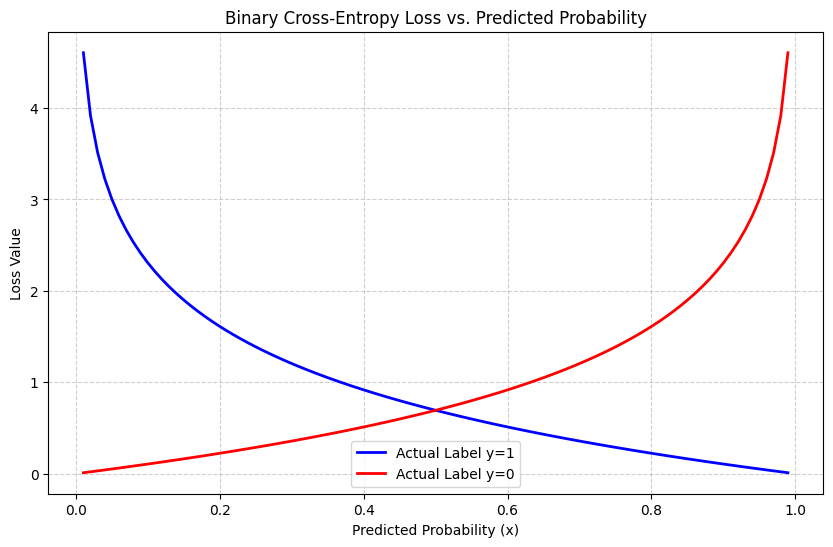

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0.01, 0.99, 100)

loss_y1 = -np.log(x)           
loss_y0 = -np.log(1 - x)      

# 3. Plotting
plt.figure(figsize=(10, 6))

plt.plot(x, loss_y1, label='Actual Label y=1', color='blue', lw=2)
plt.plot(x, loss_y0, label='Actual Label y=0', color='red', lw=2)

plt.title('Binary Cross-Entropy Loss vs. Predicted Probability')
plt.xlabel('Predicted Probability (x)')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [ ]:
y_raw_train, y_raw_val = y_train[:50000], y_train[50000:]

x_train_split, x_val_split = x_train[:50000], x_train[50000:] # (split, 28, 28)
x_train_split = x_train_split / 255.0
x_val_split = x_val_split / 255.0

model_digit_c1 = 5
model_digit_c2 = 7

# Boolean mask for samples belonging to either class
y_c1_c2_train = (y_raw_train == model_digit_c1) | (y_raw_train == model_digit_c2)  # (50000,) bool
y_c1_c2_val   = (y_raw_val   == model_digit_c1) | (y_raw_val   == model_digit_c2)  # (10000,) bool

# Filter x to only c1/c2 samples
x_train_filtered = x_train_split[y_c1_c2_train]  # (n_train, 28, 28)
x_val_filtered   = x_val_split[y_c1_c2_val]      # (n_val,   28, 28)

# Single binary label: 1 for c1, 0 for c2
y_train_filtered = (y_raw_train[y_c1_c2_train] == model_digit_c1).astype(float).reshape(-1, 1)  # (n_train, 1)
y_val_filtered   = (y_raw_val  [y_c1_c2_val]   == model_digit_c1).astype(float).reshape(-1, 1)  # (n_val,   1)

[0.]


In [98]:


def logistic_regression_binary_multi(model_digit_c1, model_digit_c2, batch_size=32, learning_rate=0.01, validation_patience=5, epsilon=1e-4):
    
    y_raw_train, y_raw_val = y_train[:50000], y_train[50000:] # (split,)

    x_train_split, x_val_split = x_train[:50000], x_train[50000:] # (split, 28, 28)
    x_train_split = x_train_split / 255.0
    x_val_split = x_val_split / 255.0

    # Boolean mask for samples belonging to either class
    y_c1_c2_train = (y_raw_train == model_digit_c1) | (y_raw_train == model_digit_c2)  # (split,) bool
    y_c1_c2_val   = (y_raw_val   == model_digit_c1) | (y_raw_val   == model_digit_c2)  # (split',) bool

    # Filter x to only c1/c2 samples
    x_train_filtered = x_train_split[y_c1_c2_train]  # (n_train, 28, 28)
    x_val_filtered   = x_val_split[y_c1_c2_val]      # (n_val,   28, 28)

    # Single binary label: 1 for c1, 0 for c2
    y_train_filtered = (y_raw_train[y_c1_c2_train] == model_digit_c1).astype(float).reshape(-1, 1)  # (n_train, 1)
    y_val_filtered   = (y_raw_val  [y_c1_c2_val]   == model_digit_c1).astype(float).reshape(-1, 1)  # (n_val,   1)

    x_train_flat = x_train_filtered.reshape(x_train_filtered.shape[0], -1) # (split, 784)
    x_train_bias = np.hstack([x_train_flat, np.ones((x_train_filtered.shape[0], 1))])  # (50000, 785, 1)

    x_val_flat = x_val_filtered.reshape(x_val_filtered.shape[0], -1)  # (split', 785)
    x_val_bias = np.hstack([x_val_flat, np.ones((x_val_filtered.shape[0], 1))]) # (split', 785)

    w = np.random.uniform(low=-0.01, high=0.01, size=(785, 1))
    best_v_loss = float('inf')
    patience = validation_patience
    counter = 0
    epoch = 0
    while True:
        for batch in range(x_train_filtered.shape[0] // batch_size):
            start = batch * batch_size
            end   = start + batch_size

            xi_batch = x_train_bias[start:end]          # (B, 785)
            z_batch  = np.dot(xi_batch, w)              # (B, 1)
            y_hat    = 1 / (1 + np.exp(-z_batch))       # (B, 1)

            error   = y_hat - y_train_filtered[start:end]   # (B, 1)
            de_dw   = np.dot(xi_batch.T, error) / batch_size  # (785, 1)
            w      -= learning_rate * de_dw
            
        z_v = np.dot(x_val_bias, w) #split'x785 * 785x1
        y_hat_v = 1 / (1 + np.exp(-z_v))

        y_hat_v = np.clip(y_hat_v, 1e-15, 1 - 1e-15) # Cap to avoid log(0) errors

        v_loss = -np.mean(y_val_filtered * np.log(y_hat_v) + (1 - y_val_filtered) * np.log(1 - y_hat_v))

        if v_loss < best_v_loss - epsilon:
            best_v_loss = v_loss
            counter = 0
        else:
            counter += 1

        if counter == patience:
            return w
        print(f"Epoch: {epoch}, Loss:  {v_loss}")
        epoch += 1


In [110]:
weights = logistic_regression_binary_multi(7, 5, 1, 0.01, 5, 1e-4)

Epoch: 0, Loss:  0.028739068758246913
Epoch: 1, Loss:  0.02325279490952122
Epoch: 2, Loss:  0.020850433564889328
Epoch: 3, Loss:  0.01947440171727111
Epoch: 4, Loss:  0.018585060518060883
Epoch: 5, Loss:  0.017968415554628882
Epoch: 6, Loss:  0.017520157010534165
Epoch: 7, Loss:  0.017182755854818696
Epoch: 8, Loss:  0.01692185311258833
Epoch: 9, Loss:  0.016715782092371165
Epoch: 10, Loss:  0.016550329741884976
Epoch: 11, Loss:  0.016415880094029053
Epoch: 12, Loss:  0.016305755067445464
Epoch: 13, Loss:  0.016215205409115967
Epoch: 14, Loss:  0.016140775951886833
Epoch: 15, Loss:  0.016079896035892362
Epoch: 16, Loss:  0.016030609875790615
Epoch: 17, Loss:  0.015991396089641403
Epoch: 18, Loss:  0.015961045145945544
Epoch: 19, Loss:  0.015938575035445348
Epoch: 20, Loss:  0.015923172518056798
Epoch: 21, Loss:  0.015914151694958165
Epoch: 22, Loss:  0.015910924455154473
Epoch: 23, Loss:  0.015912979152881992
Epoch: 24, Loss:  0.015919865052523793


In [111]:
def test_logistic_regression(w, model_digit_c1, model_digit_c2):
    
    # Filter test set to only c1/c2 samples
    y_c1_c2_test = (y_test == model_digit_c1) | (y_test == model_digit_c2)
    x_test_filtered = x_test[y_c1_c2_test] / 255.0
    y_test_filtered = (y_test[y_c1_c2_test] == model_digit_c1).astype(float).reshape(-1, 1)

    # Add bias term
    x_test_flat = x_test_filtered.reshape(x_test_filtered.shape[0], -1)         # (n_test, 784)
    x_test_bias = np.hstack([x_test_flat, np.ones((x_test_filtered.shape[0], 1))])  # (n_test, 785)

    # Forward pass
    z = np.dot(x_test_bias, w)                  # (n_test, 1)
    y_hat = 1 / (1 + np.exp(-z))                # (n_test, 1)
    y_pred = (y_hat >= 0.5).astype(float)        # (n_test, 1)

    # Metrics
    accuracy  = np.mean(y_pred == y_test_filtered)
    tp = np.sum((y_pred == 1) & (y_test_filtered == 1))
    tn = np.sum((y_pred == 0) & (y_test_filtered == 0))
    fp = np.sum((y_pred == 1) & (y_test_filtered == 0))
    fn = np.sum((y_pred == 0) & (y_test_filtered == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Test Results — {model_digit_c1} vs {model_digit_c2}")
    print(f"  Accuracy  : {accuracy * 100:.2f}%")    
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

# Usage
test_logistic_regression(weights, model_digit_c1=7, model_digit_c2=5)

Test Results — 7 vs 5
  Accuracy  : 99.27%
  Precision : 0.9932
  Recall    : 0.9932
  F1 Score  : 0.9932
  TP: 1021, TN: 885, FP: 7, FN: 7


In [109]:
from itertools import combinations

weights_dict = {}

digits = list(range(10))  # 0 → 9

for c1, c2 in combinations(digits, 2):
    print(f"Training model for {c1} vs {c2}")
    
    w = logistic_regression_binary_multi(
        c1, c2,
        batch_size=1,
        learning_rate=0.01,
        validation_patience=5,
        epsilon=1e-4
    )
    
    weights_dict[(c1, c2)] = w

Training model for 0 vs 1
Epoch: 0, Loss:  0.0051591938507043016
Epoch: 1, Loss:  0.0036153699426638352
Epoch: 2, Loss:  0.0029267032562804375
Epoch: 3, Loss:  0.0025149522056397977
Epoch: 4, Loss:  0.00223900043139733
Epoch: 5, Loss:  0.0020432742582053853
Epoch: 6, Loss:  0.0018994354131989133
Epoch: 7, Loss:  0.0017907002067074186
Epoch: 8, Loss:  0.00170628313276578
Epoch: 9, Loss:  0.0016389505399235782
Epoch: 10, Loss:  0.0015837405415557299
Epoch: 11, Loss:  0.0015372094619928833
Epoch: 12, Loss:  0.0014969552494166333
Epoch: 13, Loss:  0.001461302121422223
Epoch: 14, Loss:  0.0014290850063445255
Epoch: 15, Loss:  0.0013994984820053468
Epoch: 16, Loss:  0.0013719890676261045
Epoch: 17, Loss:  0.0013461777871675228
Epoch: 18, Loss:  0.001321804562300971
Epoch: 19, Loss:  0.0012986886768235702
Epoch: 20, Loss:  0.0012767011550204649
Epoch: 21, Loss:  0.0012557459234039258
Epoch: 22, Loss:  0.0012357473520113896
Epoch: 23, Loss:  0.0012166423296069713
Epoch: 24, Loss:  0.0011983754

In [117]:
def evaluate_digit_ovo(weights_dict, x_test, y_test, target_digit):
    
    # ---- Step 1: Predict all ----
    def predict_one(x):
        votes = {i: 0 for i in range(10)}

        x_flat = x.reshape(1, -1) / 255.0
        x_bias = np.hstack([x_flat, np.ones((1, 1))])

        for (c1, c2), w in weights_dict.items():
            z = np.dot(x_bias, w)
            y_hat = 1 / (1 + np.exp(-z))

            if y_hat >= 0.5:
                votes[c1] += 1
            else:
                votes[c2] += 1

        return max(votes, key=votes.get)

    y_pred = np.array([predict_one(x) for x in x_test])

    # ---- Step 2: Convert to binary (target vs all) ----
    y_true_bin = (y_test == target_digit).astype(int)
    y_pred_bin = (y_pred == target_digit).astype(int)

    # ---- Step 3: Compute metrics ----
    tp = np.sum((y_pred_bin == 1) & (y_true_bin == 1))
    tn = np.sum((y_pred_bin == 0) & (y_true_bin == 0))
    fp = np.sum((y_pred_bin == 1) & (y_true_bin == 0))
    fn = np.sum((y_pred_bin == 0) & (y_true_bin == 1))

    accuracy  = (tp + tn) / len(y_test)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # ---- Step 4: Print ----
    print(f"Results for digit {target_digit} vs All")
    print(f"Accuracy  : {accuracy * 100:.2f}%")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

evaluate_digit_ovo(weights_dict, x_test, y_test, 8)

Results for digit 8 vs All
Accuracy  : 98.35%
Precision : 0.9411
Recall    : 0.8860
F1 Score  : 0.9127
TP: 863, TN: 8972, FP: 54, FN: 111
